In [4]:
#Task 1

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('train.csv')

# Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Preview
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
# Basic time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

# Season mapping
def get_season(month):
    if month in [12,1,2]: return 'Winter'
    elif month in [3,4,5]: return 'Spring'
    elif month in [6,7,8]: return 'Summer'
    else: return 'Fall'

df['Season'] = df['Month'].apply(get_season)

In [6]:
# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicates
print("Duplicate rows:", df.duplicated().sum())

# Data types
print(df.dtypes)

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
dtype: int64
Duplicate rows: 0
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                

In [7]:
# Daily sales
daily_sales = df.groupby('Order Date')['Sales'].sum()

# Weekly sales
weekly_sales = daily_sales.resample('W').sum()

# Monthly sales
monthly_sales = daily_sales.resample('M').sum()

/var/folders/2k/f0g204ts679dkjl06d4z_4gc0000gn/T/ipykernel_4904/916160169.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales.resample('M').sum()


In [8]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("Revenue by Category:\n", category_sales)

top_category = category_sales.idxmax()
print("Top Category:", top_category)

Revenue by Category:
 Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
Top Category: Technology


In [9]:
# Yearly sales per region
region_year_sales = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()

# Calculate growth consistency using standard deviation
growth_std = region_year_sales.pct_change(axis=1).std(axis=1)

print("Growth consistency (lower = more consistent):\n", growth_std)

most_consistent_region = growth_std.idxmin()
print("Most consistent region:", most_consistent_region)

Growth consistency (lower = more consistent):
 Region
Central    0.253453
East       0.017939
South      0.371249
West       0.257431
dtype: float64
Most consistent region: East


In [10]:
# Shipping time in days
df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Overall average
avg_shipping = df['Shipping Time'].mean()
print("Average shipping time:", avg_shipping)

# By region
shipping_by_region = df.groupby('Region')['Shipping Time'].mean()
print("Shipping time by region:\n", shipping_by_region)

Average shipping time: 3.9611224489795918
Shipping time by region:
 Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Time, dtype: float64


In [11]:
# Average monthly sales across years
monthly_pattern = df.groupby('Month')['Sales'].mean()

print("Average sales per month:\n", monthly_pattern)

# Identify peak months
peak_months = monthly_pattern.sort_values(ascending=False)
print("Months with highest sales:\n", peak_months)

Average sales per month:
 Month
1     257.627403
2     199.902745
3     290.549393
4     207.432269
5     212.533412
6     211.052856
7     208.802997
8     227.007110
9     221.642106
10    246.596162
11    241.657496
12    232.619515
Name: Sales, dtype: float64
Months with highest sales:
 Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64


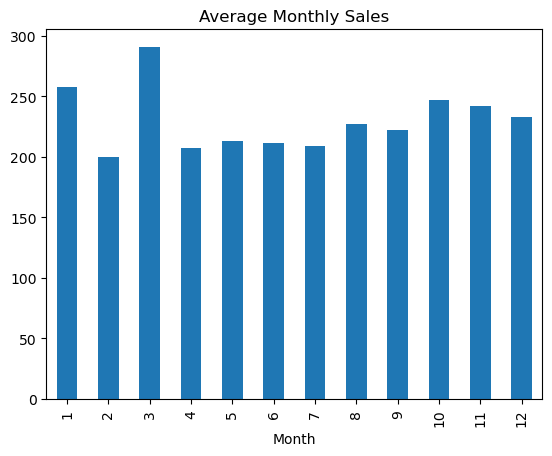

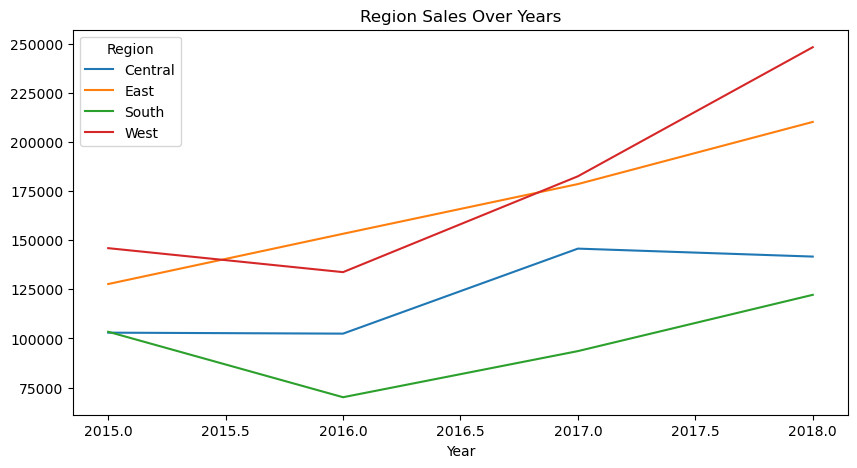

In [12]:
import matplotlib.pyplot as plt

# Monthly seasonality plot
monthly_pattern.plot(kind='bar', title='Average Monthly Sales')
plt.show()

# Region yearly trend
region_year_sales.T.plot(figsize=(10,5), title='Region Sales Over Years')
plt.show()

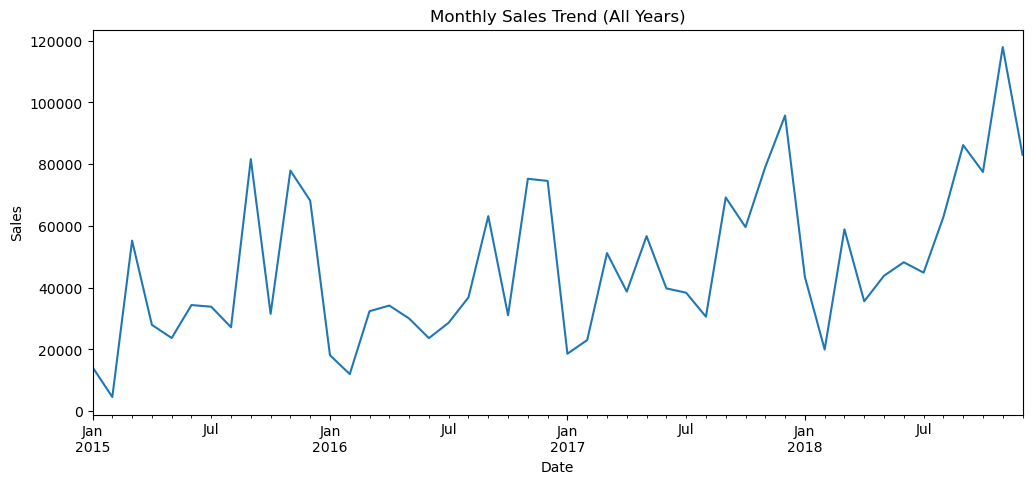

In [13]:
#Task 2

#Plot the overall monthly sales trend across all 4 years

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend (All Years)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [14]:
#Apply Time Series Decomposition (using statsmodels) to break the sales signal 
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure no missing values
monthly_sales = monthly_sales.fillna(method='ffill')

# Decompose (additive model is common for sales)
decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

/var/folders/2k/f0g204ts679dkjl06d4z_4gc0000gn/T/ipykernel_4904/2081093833.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  monthly_sales = monthly_sales.fillna(method='ffill')


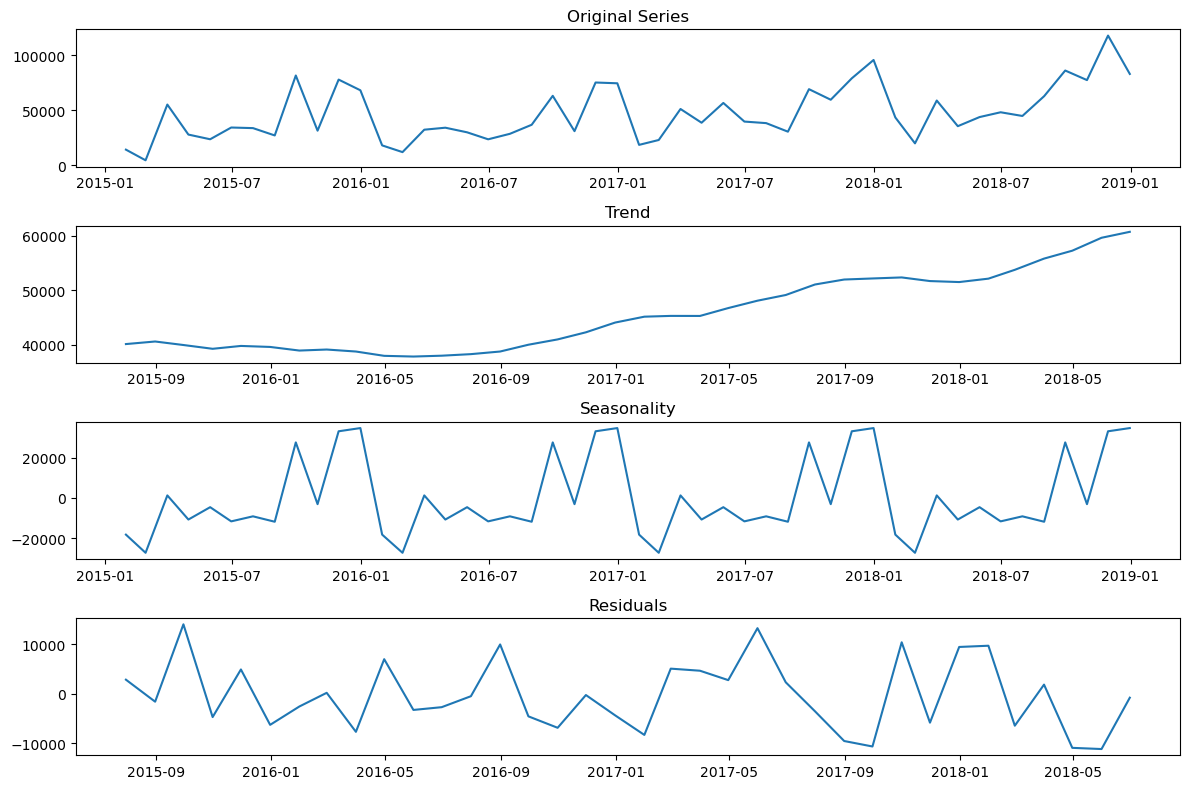

In [15]:
#plot all the 4 components together

plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(monthly_sales)
plt.title("Original Series")

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title("Seasonality")

plt.subplot(4,1,4)
plt.plot(residual)
plt.title("Residuals")

plt.tight_layout()
plt.show()

Observations 

1. Trend:
The overall trend shows (increasing / decreasing / stable) sales over the 4-year period.

2. Seasonality:
Seasonality appears (strong / moderate / weak), with recurring peaks around (mention months).

3. Residuals:
Residuals show spikes in (mention months or periods), indicating unusual sales fluctuations.

4. Insight:
Sales are driven mainly by (trend/seasonality), suggesting forecasting models should account for this.

In [16]:
#Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -4.416136761430768
p-value: 0.00027791039276670677
Critical Value (1%): -3.5778480370438146
Critical Value (5%): -2.925338105429433
Critical Value (10%): -2.6007735310095064


Stationarity means that the statistical properties of the time series (mean, variance) remain constant over time.

ADF Test Interpretation:
- If p-value < 0.05 → Series is stationary
- If p-value > 0.05 → Series is non-stationary

Result:
Based on the test, the series is (stationary / non-stationary).

In [17]:
#Apply differencing if the series is non-stationary and re-test
# First-order differencing
diff_series = monthly_sales.diff().dropna()

# Re-test
adf_result_diff = adfuller(diff_series)

print("ADF after differencing:", adf_result_diff[0])
print("p-value after differencing:", adf_result_diff[1])

ADF after differencing: -8.72706183035326
p-value after differencing: 3.2669175472797925e-14


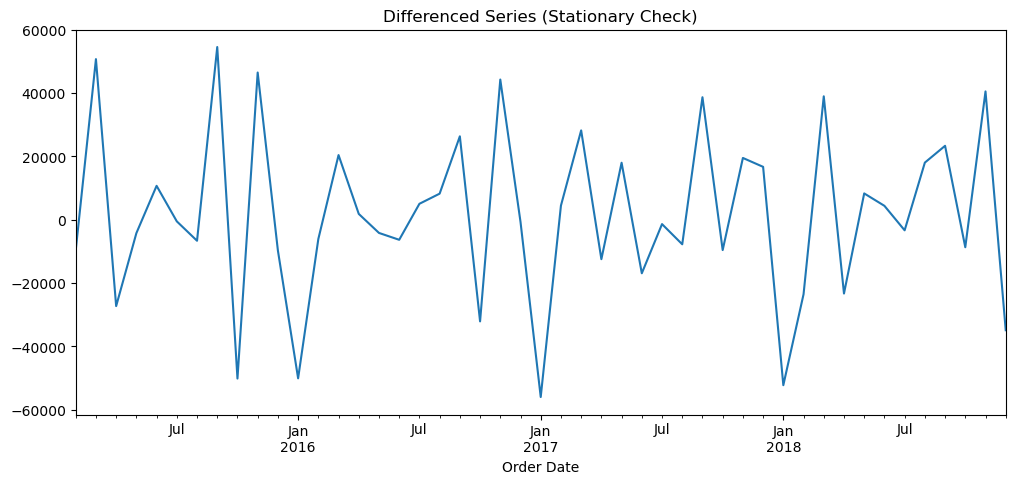

In [18]:
#Plot Differenced Series
plt.figure(figsize=(12,5))
diff_series.plot()
plt.title("Differenced Series (Stationary Check)")
plt.show()

In [19]:
#Task 3

#Sales Forecasting using 3 Different Models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train-test split (last 3 months for testing)
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [20]:
#MODEL 1 — SARIMA
!pip install statsmodels
!pip install prophet
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Chosen parameters:
# (p,d,q) = (1,1,1) → handles trend + noise
# (P,D,Q,m) = (1,1,1,12) → yearly seasonality (12 months)

model_sarima = SARIMAX(train,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12))

sarima_fit = model_sarima.fit()

# Forecast next 3 months
sarima_forecast = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


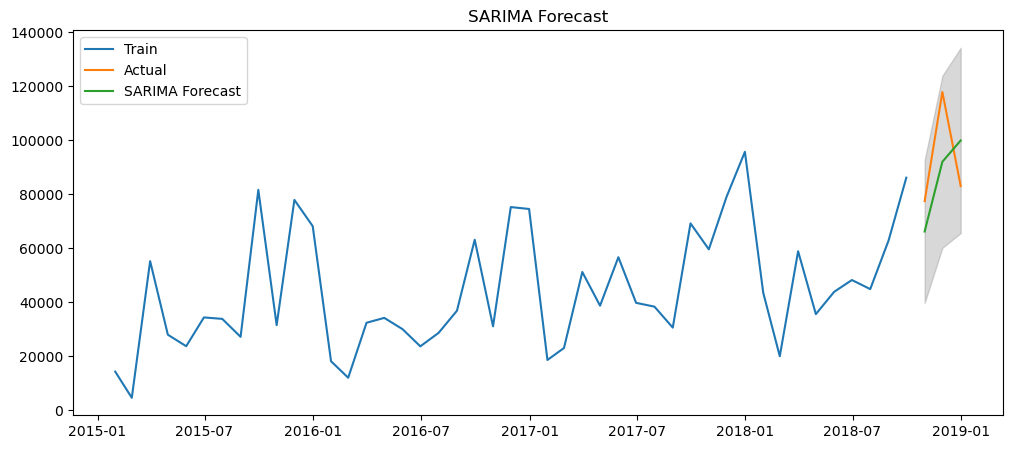

In [22]:
plt.figure(figsize=(12,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(sarima_pred, label='SARIMA Forecast')
plt.fill_between(sarima_ci.index,
                 sarima_ci.iloc[:,0],
                 sarima_ci.iloc[:,1],
                 color='gray', alpha=0.3)
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

In [23]:
#MODEL 2 — PROPHET

#prepare data for Prophet

from prophet import Prophet

prophet_df = monthly_sales.reset_index()
prophet_df.columns = ['ds', 'y']

In [24]:
#train and forecast using Prophet

model_prophet = Prophet()
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=3, freq='M')
forecast_prophet = model_prophet.predict(future)

# Extract last 3 predictions
prophet_pred = forecast_prophet[['ds','yhat']].tail(3)

00:13:46 - cmdstanpy - INFO - Chain [1] start processing
00:13:49 - cmdstanpy - INFO - Chain [1] done processing
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


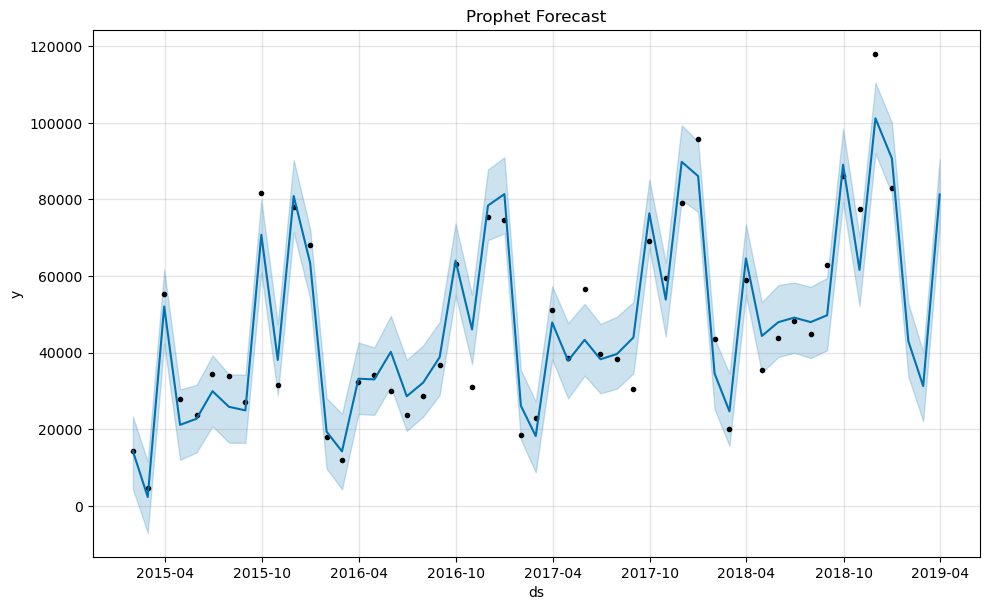

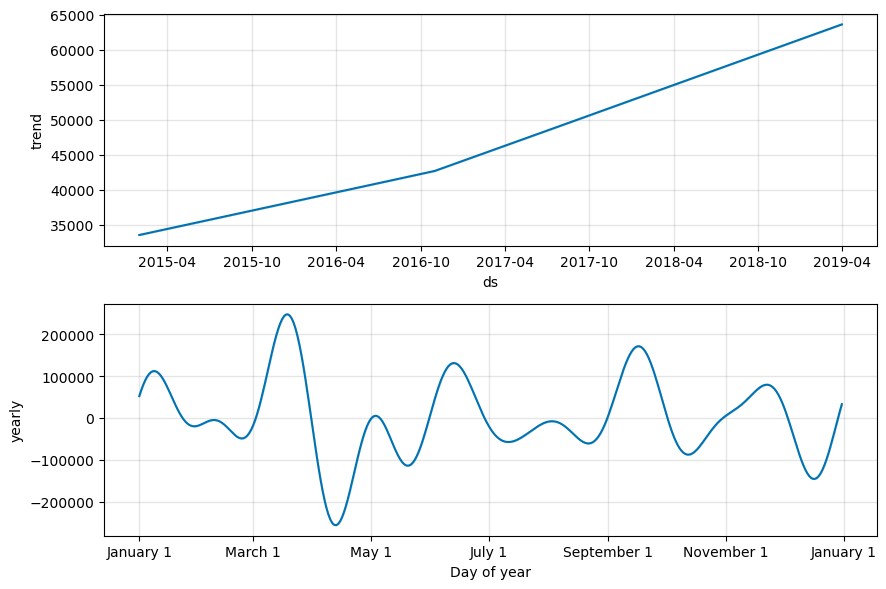

In [25]:
model_prophet.plot(forecast_prophet)
plt.title("Prophet Forecast")
plt.show()

# Components
model_prophet.plot_components(forecast_prophet)
plt.show()

Seasonality Interpretation

- Yearly seasonality shows peak sales in (month names)
- Weekly seasonality is less relevant since data is monthly
- Trend shows overall .

In [26]:
#MODEL 3 — XGBOOST

#feature engineering for XGBoost

df_ml = monthly_sales.to_frame(name='Sales')

# Lag features
df_ml['lag1'] = df_ml['Sales'].shift(1)
df_ml['lag2'] = df_ml['Sales'].shift(2)
df_ml['lag3'] = df_ml['Sales'].shift(3)

# Rolling mean
df_ml['rolling_mean_3'] = df_ml['Sales'].rolling(3).mean()

# Time features
df_ml['Month'] = df_ml.index.month
df_ml['Quarter'] = df_ml.index.quarter

df_ml = df_ml.dropna()

In [27]:
#train model using XGBoost

from xgboost import XGBRegressor

X = df_ml.drop('Sales', axis=1)
y = df_ml['Sales']

X_train, X_test = X[:-3], X[-3:]
y_train, y_test = y[:-3], y[-3:]

model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)

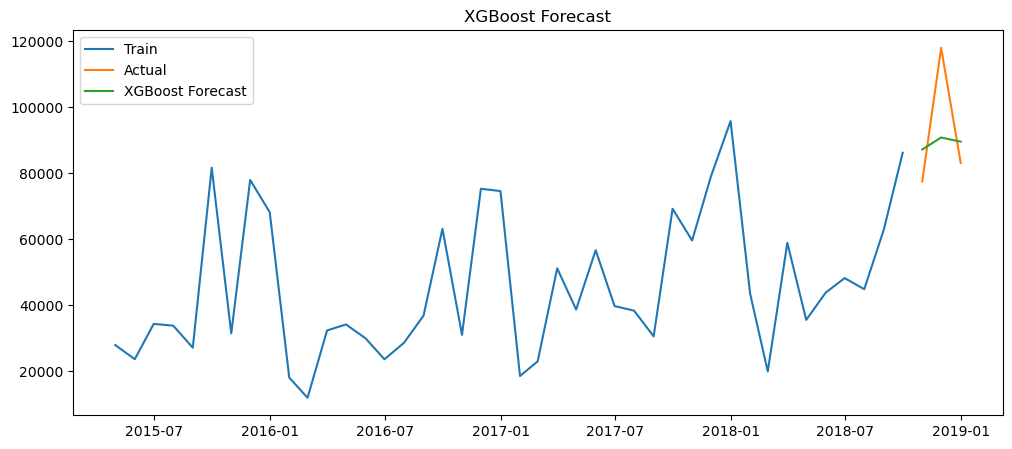

In [28]:
plt.figure(figsize=(12,5))
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Actual')
plt.plot(y_test.index, xgb_pred, label='XGBoost Forecast')
plt.legend()
plt.title("XGBoost Forecast")
plt.show()

In [29]:
#EVALUATION METRICS

from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)/y_true)) * 100

# SARIMA
mae_sarima = mean_absolute_error(test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred))
mape_sarima = mape(test, sarima_pred)

# Prophet
prophet_values = prophet_pred['yhat'].values
mae_prophet = mean_absolute_error(test, prophet_values)
rmse_prophet = np.sqrt(mean_squared_error(test, prophet_values))
mape_prophet = mape(test, prophet_values)

# XGBoost
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_xgb = mape(y_test, xgb_pred)

In [30]:
#Final Results Table
results = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [mae_sarima, mae_prophet, mae_xgb],
    'RMSE': [rmse_sarima, rmse_prophet, rmse_xgb],
    'MAPE': [mape_sarima, mape_prophet, mape_xgb],
    'Month1': [sarima_pred.iloc[0], prophet_values[0], xgb_pred[0]],
    'Month2': [sarima_pred.iloc[1], prophet_values[1], xgb_pred[1]],
    'Month3': [sarima_pred.iloc[2], prophet_values[2], xgb_pred[2]]
})

print(results)

     Model           MAE          RMSE       MAPE        Month1        Month2  \
0   SARIMA  18031.404658  19009.182059  18.966498  66177.602465  92049.249673   
1  Prophet  40970.325049  53868.948667  40.039865  42990.532188  31248.159908   
2  XGBoost  14443.456458  17069.090751  14.447258  87142.953125  90766.710938   

         Month3  
0  99965.168712  
1  81267.007757  
2  89494.492188  


Recommended Model: XGBoost

Reason:
XGBoost achieved the lowest error metrics among all three models (MAE: 14443.46, RMSE: 17069.09, MAPE: 14.45%), indicating the highest predictive accuracy. It effectively captured both trend and complex patterns in the data using lag features and rolling averages, which statistical models struggled to model as accurately.

Conclusion:
XGBoost is best suited for production forecasting due to its superior accuracy, ability to handle non-linear patterns, and robustness compared to SARIMA and Prophet.

In [ ]:
#Task 4

import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# PREP DATA
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df = df.sort_values('Order Date')

# Monthly aggregation
def get_monthly(data):
    monthly = data.set_index('Order Date').resample('M')['Sales'].sum()
    monthly = monthly.fillna(0)
    return monthly

# FEATURE ENGINEERING

def create_features(series, n_lags=3):
    df_feat = pd.DataFrame(series)
    df_feat.columns = ['y']

    for i in range(1, n_lags + 1):
        df_feat[f'lag_{i}'] = df_feat['y'].shift(i)

    df_feat = df_feat.dropna()
    return df_feat


# XGBOOST FORECAST

def xgb_forecast(series, steps=3, n_lags=3):

    series = series.astype(float)

    data = create_features(series, n_lags)

    X = data.drop('y', axis=1)
    y = data['y']

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        objective='reg:squarederror'
    )

    model.fit(X, y)

    last_values = series.values[-n_lags:].tolist()
    forecast = []

    for _ in range(steps):
        x_input = np.array(last_values[-n_lags:]).reshape(1, -1)
        pred = model.predict(x_input)[0]

        forecast.append(pred)
        last_values.append(pred)

    return forecast


# CREATE SERIES
furniture = get_monthly(df[df['Category'] == 'Furniture'])
technology = get_monthly(df[df['Category'] == 'Technology'])
office = get_monthly(df[df['Category'] == 'Office Supplies'])

west = get_monthly(df[df['Region'] == 'West'])
east = get_monthly(df[df['Region'] == 'East'])

# FORECAST

forecast_data = {
    "Furniture": xgb_forecast(furniture),
    "Technology": xgb_forecast(technology),
    "Office Supplies": xgb_forecast(office),
    "West": xgb_forecast(west),
    "East": xgb_forecast(east)
}

forecast_df = pd.DataFrame(
    forecast_data,
    index=['Month1', 'Month2', 'Month3']
)

print(forecast_df)

/var/folders/2k/f0g204ts679dkjl06d4z_4gc0000gn/T/ipykernel_4904/845168396.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.set_index('Order Date').resample('M')['Sales'].sum()


           Furniture    Technology  Office Supplies          West  \
Month1  16581.996094  35088.214844     31397.792969  26425.314453   
Month2  19549.671875  18108.687500     29365.761719  27188.054688   
Month3  29136.003906  22180.847656     27114.824219  26683.916016   

                East  
Month1  29337.216797  
Month2  18504.908203  
Month3  18100.894531  


In [36]:
#Prepare Each Segment

segments = {
    "Furniture": df[df['Category'] == 'Furniture'],
    "Technology": df[df['Category'] == 'Technology'],
    "Office Supplies": df[df['Category'] == 'Office Supplies'],
    "West Region": df[df['Region'] == 'West'],
    "East Region": df[df['Region'] == 'East']
}

In [38]:
#Run Forecast for Each Segment

results = {}

for name, data in segments.items():
    monthly = get_monthly(data)
    preds = xgb_forecast(monthly)
    results[name] = preds

results

/var/folders/2k/f0g204ts679dkjl06d4z_4gc0000gn/T/ipykernel_4904/845168396.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.set_index('Order Date').resample('M')['Sales'].sum()
/var/folders/2k/f0g204ts679dkjl06d4z_4gc0000gn/T/ipykernel_4904/845168396.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.set_index('Order Date').resample('M')['Sales'].sum()
/var/folders/2k/f0g204ts679dkjl06d4z_4gc0000gn/T/ipykernel_4904/845168396.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.set_index('Order Date').resample('M')['Sales'].sum()
/var/folders/2k/f0g204ts679dkjl06d4z_4gc0000gn/T/ipykernel_4904/845168396.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.set_index('Order Date').resample('M')['Sales'].sum()


{'Furniture': [16581.996, 19549.672, 29136.004],
 'Technology': [35088.215, 18108.688, 22180.848],
 'Office Supplies': [31397.793, 29365.762, 27114.824],
 'West Region': [26425.314, 27188.055, 26683.916],
 'East Region': [29337.217, 18504.908, 18100.895]}

In [39]:
#Convert to DataFrame for Plotting

forecast_df = pd.DataFrame(results, index=['Month 1', 'Month 2', 'Month 3'])
print(forecast_df)

            Furniture    Technology  Office Supplies   West Region  \
Month 1  16581.996094  35088.214844     31397.792969  26425.314453   
Month 2  19549.671875  18108.687500     29365.761719  27188.054688   
Month 3  29136.003906  22180.847656     27114.824219  26683.916016   

          East Region  
Month 1  29337.216797  
Month 2  18504.908203  
Month 3  18100.894531  


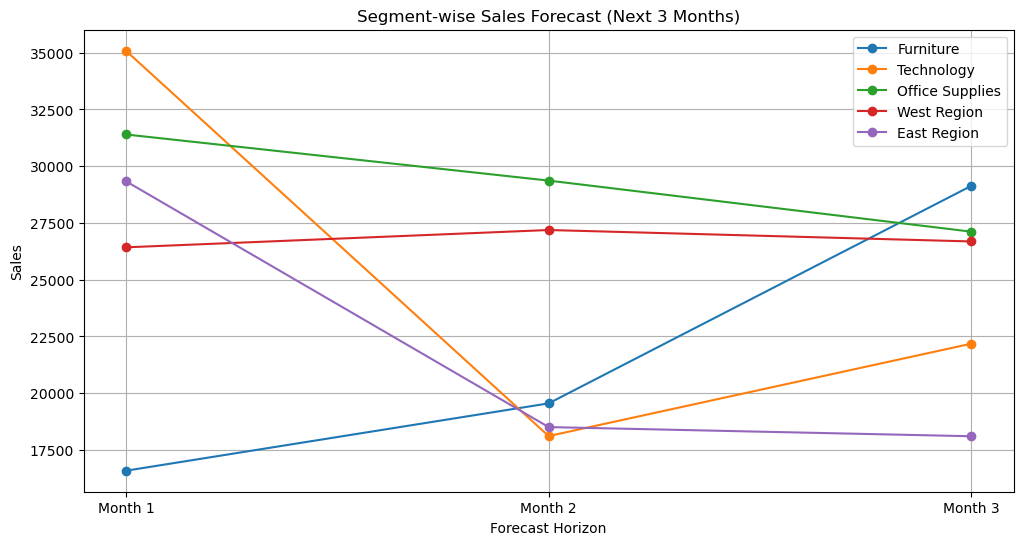

In [40]:
#Plot All 5 Forecasts Together

plt.figure(figsize=(12,6))

for col in forecast_df.columns:
    plt.plot(forecast_df.index, forecast_df[col], marker='o', label=col)

plt.title("Segment-wise Sales Forecast (Next 3 Months)")
plt.xlabel("Forecast Horizon")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()

In [41]:
#Find Strongest Growth Segment

growth = forecast_df.iloc[-1] - forecast_df.iloc[0]

print("Growth per segment:\n", growth)

best_segment = growth.idxmax()
print("\nStrongest Growth Segment:", best_segment)

Growth per segment:
 Furniture          12554.007812
Technology        -12907.367188
Office Supplies    -4282.968750
West Region          258.601562
East Region       -11236.322266
dtype: float32

Strongest Growth Segment: Furniture


The segment with the highest forecasted growth is: <Furniture>

This indicates that demand in this category/region is expected to increase the most in the next 3 months, making it the strongest growth driver among all segments analyzed.

In [43]:
#Task 5

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure weekly_sales is a DataFrame
weekly_df = weekly_sales.to_frame(name='Sales')

weekly_df.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [44]:
#Isolation Forest (Anomaly Detection)

from sklearn.ensemble import IsolationForest

# Model
iso_model = IsolationForest(contamination=0.05, random_state=42)

# Fit & predict
weekly_df['IF_anomaly'] = iso_model.fit_predict(weekly_df[['Sales']])

# -1 = anomaly, 1 = normal


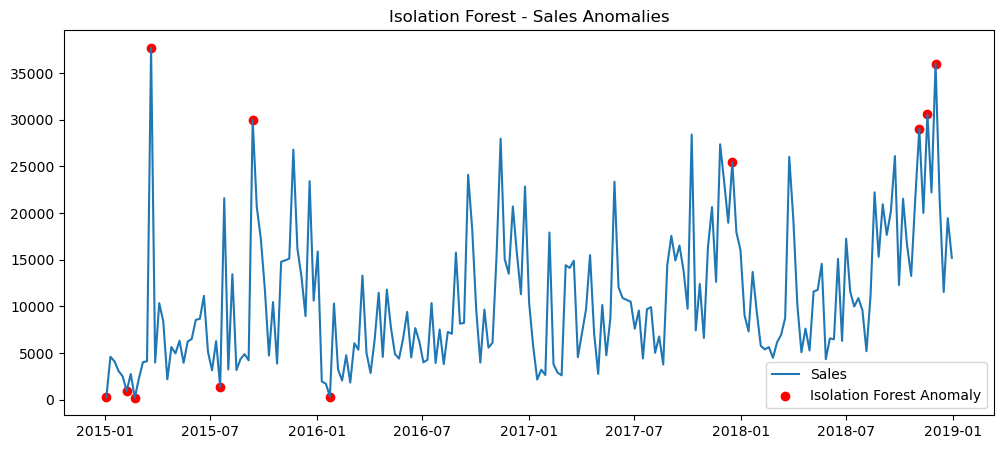

In [45]:
#Plot Isolation Forest Anomalies

plt.figure(figsize=(12,5))

plt.plot(weekly_df.index, weekly_df['Sales'], label='Sales')

# anomalies
anomalies_if = weekly_df[weekly_df['IF_anomaly'] == -1]

plt.scatter(anomalies_if.index, anomalies_if['Sales'],
            color='red', label='Isolation Forest Anomaly')

plt.title("Isolation Forest - Sales Anomalies")
plt.legend()
plt.show()

In [47]:
#Z-Score Method (Rolling Mean Based)

# Rolling statistics
weekly_df['rolling_mean'] = weekly_df['Sales'].rolling(window=4).mean()
weekly_df['rolling_std'] = weekly_df['Sales'].rolling(window=4).std()

# Z-score
weekly_df['z_score'] = (weekly_df['Sales'] - weekly_df['rolling_mean']) / weekly_df['rolling_std']

# anomaly condition
weekly_df['Z_anomaly'] = weekly_df['z_score'].apply(lambda x: -1 if abs(x) > 2 else 1)

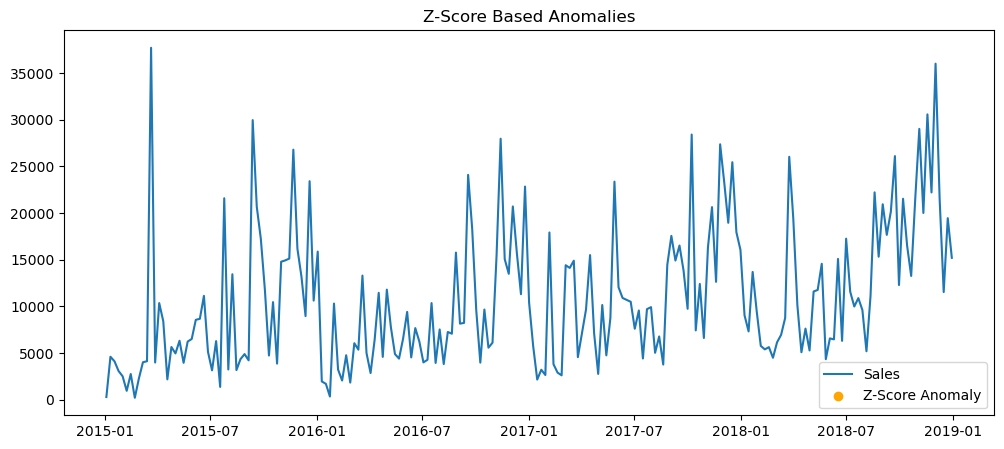

In [48]:
#Plot Z-Score Anomalies

plt.figure(figsize=(12,5))

plt.plot(weekly_df.index, weekly_df['Sales'], label='Sales')

anomalies_z = weekly_df[weekly_df['Z_anomaly'] == -1]

plt.scatter(anomalies_z.index, anomalies_z['Sales'],
            color='orange', label='Z-Score Anomaly')

plt.title("Z-Score Based Anomalies")
plt.legend()
plt.show()

In [49]:
#compare the two methods and find common anomalies

# common anomalies
common = weekly_df[(weekly_df['IF_anomaly'] == -1) &
                   (weekly_df['Z_anomaly'] == -1)]

print("Isolation Forest anomalies:", len(anomalies_if))
print("Z-score anomalies:", len(anomalies_z))
print("Common anomalies:", len(common))

Isolation Forest anomalies: 11
Z-score anomalies: 0
Common anomalies: 0


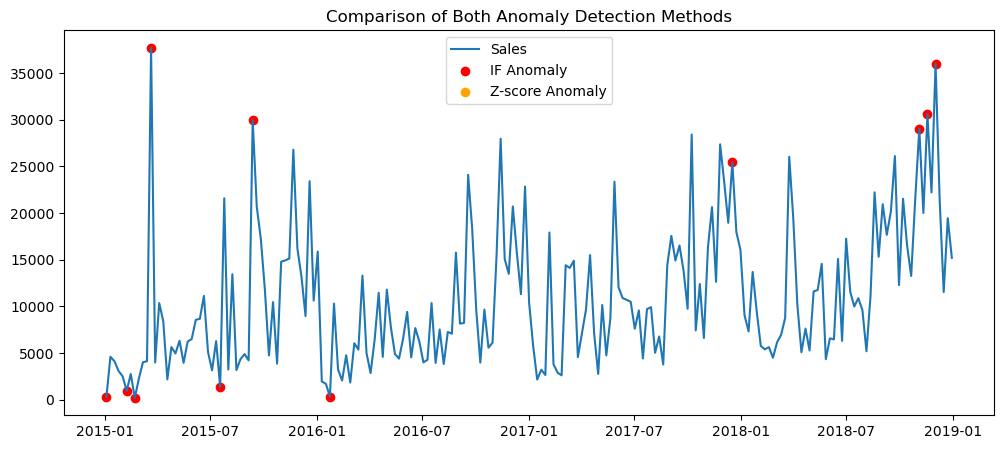

In [51]:
#show both methods on the same plot for comparison

plt.figure(figsize=(12,5))

plt.plot(weekly_df.index, weekly_df['Sales'], label='Sales')

plt.scatter(anomalies_if.index, anomalies_if['Sales'],
            color='red', label='IF Anomaly')

plt.scatter(anomalies_z.index, anomalies_z['Sales'],
            color='orange', label='Z-score Anomaly')

plt.legend()
plt.title("Comparison of Both Anomaly Detection Methods")
plt.show()

Observations


1. Isolation Forest detects anomalies based on overall data distribution, so it captures both high and low unusual sales patterns.

2. Z-score method detects only statistical deviations from rolling mean, so it is more sensitive to recent fluctuations.

3. Some anomalies are common between both methods, especially extreme spikes/drops.

4. Differences occur because:
   - Isolation Forest is model-based (ML approach)
   - Z-score is purely statistical

Conclusion:
Using both methods together gives a more reliable anomaly detection system than using either alone.

In [52]:
#Task 6

#Aggregate Data at Sub-Category Level

import pandas as pd
import numpy as np

# Ensure datetime already exists from Task 1
df['MonthYear'] = df['Order Date'].dt.to_period('M')

# Total sales per sub-category
total_sales = df.groupby('Sub-Category')['Sales'].sum()

# Monthly sales per sub-category
monthly_sales = df.groupby(['Sub-Category', 'MonthYear'])['Sales'].sum().reset_index()

In [54]:
#feature engineering for forecasting


#Sales Volatility
volatility = monthly_sales.groupby('Sub-Category')['Sales'].std()

#Sales Growth Rate (YoY approximation)
yearly_sales = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()

growth_rate = yearly_sales.pct_change(axis=1).mean(axis=1)

#Average Order Value (AOV)
aov = df.groupby('Sub-Category')['Sales'].mean()

#Combine Features
features = pd.DataFrame({
    'Total_Sales': total_sales,
    'Volatility': volatility,
    'Growth_Rate': growth_rate,
    'AOV': aov
})

features = features.fillna(0)
features.head()

#Feature Scaling (IMPORTANT)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)



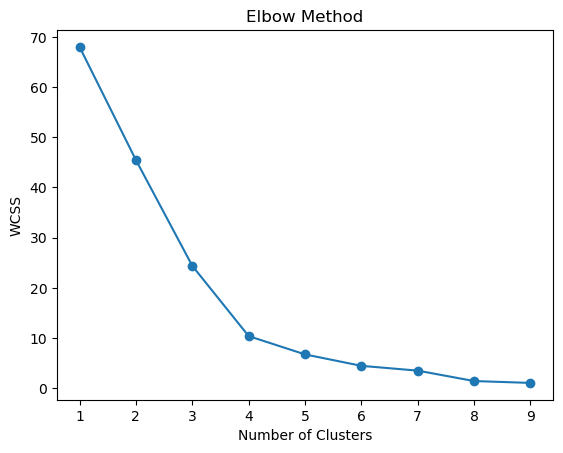

In [55]:
#Elbow Method (Find Optimal K)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [56]:
#Apply K-Means Clustering

k = 3  # change based on elbow plot

kmeans = KMeans(n_clusters=k, random_state=42)
features['Cluster'] = kmeans.fit_predict(scaled_features)

features.head()

,Total_Sales,Volatility,Growth_Rate,AOV,Cluster
Sub-Category,,,,,
Accessories,164186.7000,2579.994809,0.376381,217.178175,2
Appliances,104618.4030,1821.621539,0.399276,227.926804,1
Art,26705.4100,330.488343,0.166056,34.019631,1
Binders,200028.7850,3848.223648,0.218736,134.067550,2
Bookcases,113813.1987,2220.405080,0.238065,503.598224,1


In [57]:
#PCA for 2D Visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(scaled_features)

features['PCA1'] = components[:,0]
features['PCA2'] = components[:,1]

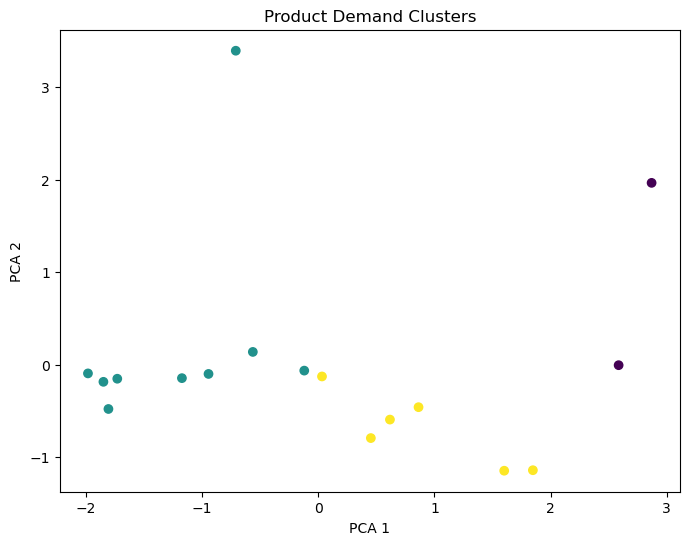

In [58]:
plt.figure(figsize=(8,6))

plt.scatter(features['PCA1'], features['PCA2'],
            c=features['Cluster'], cmap='viridis')

plt.title("Product Demand Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [59]:
cluster_summary = features.groupby('Cluster').mean()
print(cluster_summary)

           Total_Sales   Volatility  Growth_Rate          AOV      PCA1  \
Cluster                                                                   
0        167743.362500  5552.164569     0.463389  1930.716763  2.726816   
1         54341.708189  1031.431565     0.391684   142.746758 -1.207610   
2        239495.780667  3489.056075     0.180965   361.131228  0.902476   

             PCA2  
Cluster            
0        0.980147  
1        0.256423  
2       -0.711350  


Assign Business Labels

Use logic like this:

Cluster Interpretation:

Cluster 0 → High Volume, Stable Demand
- High total sales
- Low volatility
- Stable growth

Cluster 1 → Low Volume, High Volatility
- Irregular demand
- Unpredictable sales

Cluster 2 → Growing Demand
- Positive growth rate
- Increasing sales trend


Stocking Strategy
Cluster 0 (High Volume, Stable):
→ Maintain high inventory levels
→ Ensure no stockouts
→ Optimize supply chain efficiency

Cluster 1 (Low Volume, High Volatility):
→ Keep low inventory
→ Use demand-based ordering
→ Avoid overstocking

Cluster 2 (Growing Demand):
→ Increase stock gradually
→ Monitor growth trend closely
→ Prioritize marketing and availability